# ENS Challenge 60 - Stock Auction Volume Prediction
## Main Pipeline Notebook

**Goal**: Predict the natural logarithm of closing auction volume (as a fraction of total daily volume) for 900 stocks.

**Metric**: RMSE (Root Mean Squared Error)

**Benchmark**: 0.4742 RMSE

## 1. Setup and Imports

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print('Standard imports loaded!')

Standard imports loaded!


In [2]:
# Import custom utilities
import sys
sys.path.insert(0, '.')

from utils.data_loader import (
    load_config, load_data, merge_target, get_feature_columns,
    create_submission, print_data_info
)
from utils.preprocessing import preprocess_data, handle_missing_values
from utils.feature_engineering import (
    create_features, create_aggregation_features, create_domain_features,
    create_nlv_features, create_day_features, get_feature_list
)
from utils.validation import (
    TimeSeriesValidator, compute_metrics, cross_validate,
    create_temporal_split, print_cv_summary
)
from utils.models import (
    TwoStageModel, train_lightgbm, train_linear,
    get_model, train_and_evaluate
)
from utils.mlflow_utils import setup_mlflow, log_experiment, ExperimentTracker
from utils.visualization import (
    plot_feature_importance, plot_residuals, plot_predictions,
    plot_cv_results, plot_target_distribution, create_summary_dashboard
)

print('Custom utilities loaded!')

Custom utilities loaded!


In [3]:
# Load configuration
config = load_config('configs/config.yaml')
print('Configuration loaded!')
print(f'Train input: {config["data"]["train_input"]}')
print(f'Train output: {config["data"]["train_output"]}')
print(f'Test input: {config["data"]["test_input"]}')

Configuration loaded!
Train input: data/input_training.csv.gz
Train output: data/output_training_IxKGwDV.csv
Test input: data/input_test.csv.gz


## 2. Data Loading

In [4]:
# Load data with memory optimization
X_train_raw, y_train, X_test_raw = load_data(config=config, load_test=True, verbose=True)

Loading training input data...
  Shape: (684482, 127)
  Memory: 347.72 MB
Loading training output data...
  Shape: (684482, 2)
Loading test input data...
  Shape: (311744, 127)
  Memory: 158.37 MB


In [5]:
# Print data info
print_data_info(X_train_raw, 'Training Data', config)
print_data_info(X_test_raw, 'Test Data', config)


Training Data Information
Samples:        684,482
Features:       127
Stocks:         900
Days:           805
Day Range:      (np.int16(0), np.int16(804))
Memory:         347.72 MB
Missing Returns: 1,907,741
Missing Volumes: 1,907,741


Test Data Information
Samples:        311,744
Features:       127
Stocks:         900
Days:           347
Day Range:      (np.int16(805), np.int16(1151))
Memory:         158.37 MB
Missing Returns: 702,183
Missing Volumes: 702,183



In [6]:
# Check target distribution
print('Target Statistics:')
print(y_train.describe())

Target Statistics:
                 ID         target
count  6.844820e+05  684482.000000
mean   6.862229e+05      -1.958691
std    4.166922e+05       0.909245
min    1.480000e+02      -7.137686
25%    3.259202e+05      -2.513789
50%    6.630995e+05      -1.948804
75%    1.006950e+06      -1.395366
max    1.536859e+06       3.580919


In [ ]:
# Validate target alignment on raw files (strict, assertion-driven)
target_col = config['features']['target_col']
raw_aligned = merge_target(
    X_train_raw,
    y_train,
    config,
    align_mode='auto',
    strict=True,
)

assert len(raw_aligned) == len(X_train_raw), 'Aligned training length mismatch'
assert target_col in raw_aligned.columns, 'Target column missing after merge'
assert raw_aligned[target_col].isna().sum() == 0, 'Unexpected NaN targets after strict merge'
assert 'ID' in raw_aligned.columns and raw_aligned['ID'].equals(X_train_raw['ID']), 'ID order changed during alignment'

print('Strict target alignment checks passed on raw data')
print(f'Rows: {len(raw_aligned):,}, Target NaNs: {raw_aligned[target_col].isna().sum()}')


## 3. Data Exploration

In [ ]:
# Check for missing values on raw training features
feature_cols = get_feature_columns(config)
return_cols = feature_cols['return_cols']
volume_cols = feature_cols['volume_cols']

print('Missing values in returns:', X_train_raw[return_cols].isnull().sum().sum())
print('Missing values in volumes:', X_train_raw[volume_cols].isnull().sum().sum())
print('Missing values in LS:', X_train_raw['LS'].isnull().sum())
print('Missing values in NLV:', X_train_raw['NLV'].isnull().sum())


In [ ]:
# Plot target distribution from raw target file
fig = plot_target_distribution(y_train[target_col].values, title='Target Distribution (Raw Target File)')
plt.show()


In [ ]:
# Check day range from raw training input
day_col = config['features']['day_col']
print(f'Training days: {X_train_raw[day_col].min()} to {X_train_raw[day_col].max()}')
print(f'Number of unique days: {X_train_raw[day_col].nunique()}')
print(f'Number of unique stocks: {X_train_raw[config["features"]["id_col"]].nunique()}')


## 4. Preprocessing

In [11]:
# Preprocess training data
X_train_processed, _, X_test_processed = preprocess_data(
    X_train_raw, y_train, X_test_raw, config=config, verbose=True
)


PREPROCESSING PIPELINE

Processing training data...
Missing values before: 3,815,482
Created NaN count features: return_nan_count, volume_nan_count, total_nan_count
Missing values after: 0

Processing test data...
Missing values before: 1,404,366
Created NaN count features: return_nan_count, volume_nan_count, total_nan_count
Missing values after: 0

Preprocessing complete!



In [ ]:
# Merge target once after preprocessing (strict, assertion-driven)
train_df = merge_target(
    X_train_processed,
    y_train,
    config,
    align_mode='auto',
    strict=True,
)

assert len(train_df) == len(X_train_processed), 'Processed merge changed row count'
assert train_df[target_col].isna().sum() == 0, 'Processed merge introduced NaN targets'
assert train_df['ID'].equals(X_train_processed['ID']), 'Processed merge changed ID order'

print(f'Processed training data shape: {train_df.shape}')
print('Strict merge checks passed for processed training data')


## 5. Feature Engineering

In [ ]:
# Create features for training data (includes non-leaky temporal features)
train_df = create_features(
    train_df,
    config=config,
    include_aggregations=True,
    include_domain=True,
    include_non_leaky_temporal=True,
    include_nlv=True,
    include_day=True,
    include_temporal=False,
    verbose=True
)


In [ ]:
# Create features for test data (with training history bridge for temporal features)
X_test_processed = create_features(
    X_test_processed,
    config=config,
    include_aggregations=True,
    include_domain=True,
    include_non_leaky_temporal=True,
    temporal_history_df=train_df,
    include_nlv=True,
    include_day=True,
    include_temporal=False,
    verbose=True
)


In [15]:
# Get feature list for modeling (include pid as categorical feature)
feature_list, categorical_cols = get_feature_list(train_df, config, exclude_raw=False, exclude_target=True, include_id=True)
print(f'Total features for modeling: {len(feature_list)}')
print(f'Categorical features: {categorical_cols}')
print(f'Feature list (first 30): {feature_list[:30]}')

Total features for modeling: 165
Categorical features: ['pid']
Feature list (first 30): ['pid', 'abs_ret0', 'abs_ret1', 'abs_ret2', 'abs_ret3', 'abs_ret4', 'abs_ret5', 'abs_ret6', 'abs_ret7', 'abs_ret8', 'abs_ret9', 'abs_ret10', 'abs_ret11', 'abs_ret12', 'abs_ret13', 'abs_ret14', 'abs_ret15', 'abs_ret16', 'abs_ret17', 'abs_ret18', 'abs_ret19', 'abs_ret20', 'abs_ret21', 'abs_ret22', 'abs_ret23', 'abs_ret24', 'abs_ret25', 'abs_ret26', 'abs_ret27', 'abs_ret28']


## 6. Train/Validation Split

In [16]:
# Create temporal split
max_day = train_df[day_col].max()
train_end_day = int(max_day * 0.85)

print(f'Max day: {max_day}')
print(f'Train end day: {train_end_day}')

train_split, val_split, _ = create_temporal_split(
    train_df, train_end_day=train_end_day, config=config
)

print(f'Training samples: {len(train_split):,}')
print(f'Validation samples: {len(val_split):,}')

Max day: 804
Train end day: 683
Training samples: 293,710
Validation samples: 61,519


In [17]:
# Prepare features and target
target_col = config['features']['target_col']

X_train = train_split[feature_list]
y_train_split = train_split[target_col]

X_val = val_split[feature_list]
y_val = val_split[target_col]

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')

X_train shape: (293710, 165)
X_val shape: (61519, 165)


## 7. Model Training

### 7.1 Baseline: Linear Regression on NLV

In [18]:
from sklearn.linear_model import Ridge

nlv_model = Ridge(alpha=1.0)
nlv_model.fit(X_train[['NLV']], y_train_split)

nlv_train_pred = nlv_model.predict(X_train[['NLV']])
nlv_val_pred = nlv_model.predict(X_val[['NLV']])

nlv_train_metrics = compute_metrics(y_train_split.values, nlv_train_pred)
nlv_val_metrics = compute_metrics(y_val.values, nlv_val_pred)

print('=' * 50)
print('BASELINE: Linear Regression on NLV only')
print('=' * 50)
print(f'Train RMSE: {nlv_train_metrics["rmse"]:.4f}')
print(f'Val RMSE:   {nlv_val_metrics["rmse"]:.4f}')
print(f'Val R2:     {nlv_val_metrics["r2"]:.4f}')

BASELINE: Linear Regression on NLV only
Train RMSE: 0.9266
Val RMSE:   0.8687
Val R2:     -0.0683


### 7.2 Two-Stage Model (CFM Benchmark)

In [19]:
two_stage_model = TwoStageModel(
    linear_alpha=1.0,
    lgb_params=config['models']['lightgbm']['params'],
    categorical_features=categorical_cols if categorical_cols else None,
    early_stopping_rounds=50,
    config=config
)

two_stage_model.fit(X_train, y_train_split, X_val=X_val, y_val=y_val)

ts_train_pred = two_stage_model.predict(X_train)
ts_val_pred = two_stage_model.predict(X_val)

ts_train_metrics = compute_metrics(y_train_split.values, ts_train_pred)
ts_val_metrics = compute_metrics(y_val.values, ts_val_pred)

print('=' * 50)
print('TWO-STAGE MODEL: Linear + LightGBM')
print('=' * 50)
print(f'Train RMSE: {ts_train_metrics["rmse"]:.4f}')
print(f'Val RMSE:   {ts_val_metrics["rmse"]:.4f}')
print(f'Val R2:     {ts_val_metrics["r2"]:.4f}')

TWO-STAGE MODEL: Linear + LightGBM
Train RMSE: 0.7428
Val RMSE:   0.8008
Val R2:     0.0923


### 7.3 LightGBM Only

In [20]:
import lightgbm as lgb

lgb_params = config['models']['lightgbm']['params'].copy()
lgb_model = lgb.LGBMRegressor(**lgb_params)

# Use categorical_cols from get_feature_list (or empty list if none)
cat_features = categorical_cols if categorical_cols else 'auto'

lgb_model.fit(
    X_train, y_train_split,
    eval_set=[(X_val, y_val)],
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

lgb_train_pred = lgb_model.predict(X_train)
lgb_val_pred = lgb_model.predict(X_val)

lgb_train_metrics = compute_metrics(y_train_split.values, lgb_train_pred)
lgb_val_metrics = compute_metrics(y_val.values, lgb_val_pred)

print('=' * 50)
print('LIGHTGBM ONLY')
print('=' * 50)
print(f'Train RMSE: {lgb_train_metrics["rmse"]:.4f}')
print(f'Val RMSE:   {lgb_val_metrics["rmse"]:.4f}')
print(f'Val R2:     {lgb_val_metrics["r2"]:.4f}')

LIGHTGBM ONLY
Train RMSE: 0.7191
Val RMSE:   0.8076
Val R2:     0.0769


## 8. Cross-Validation

In [ ]:
print('=' * 50)
print('TIME SERIES CROSS-VALIDATION (NO DAY LEAKAGE)')
print('=' * 50)

# Keep day out of model features; use split_df for temporal fold construction
X_full = train_df[feature_list]
y_full = train_df[target_col]
split_df = train_df[[day_col]]

validator = TimeSeriesValidator(n_splits=5, gap=5, config=config)

lgb_cv_model = lgb.LGBMRegressor(**lgb_params)
cv_results = cross_validate(
    model=lgb_cv_model,
    X=X_full,
    y=y_full,
    validator=validator,
    split_df=split_df,
    fit_kwargs={'categorical_feature': cat_features},
    config=config,
    verbose=True
)


In [22]:
print_cv_summary(cv_results)


CROSS-VALIDATION SUMMARY
RMSE: 0.9222 ± 0.0868
MAE:  0.7117 ± 0.0733
R²:   -0.0398 ± 0.1394

Per-Fold Results:
    rmse      mae        r2  fold  train_size  val_size
1.014295 0.790048 -0.241754     1       54210     57443
0.860043 0.657196  0.067221     2      111653     59922
1.015324 0.790888 -0.122657     3      171575     56948
0.888191 0.679681  0.086653     4      228523     58158
0.833019 0.640442  0.011364     5      286681     68041



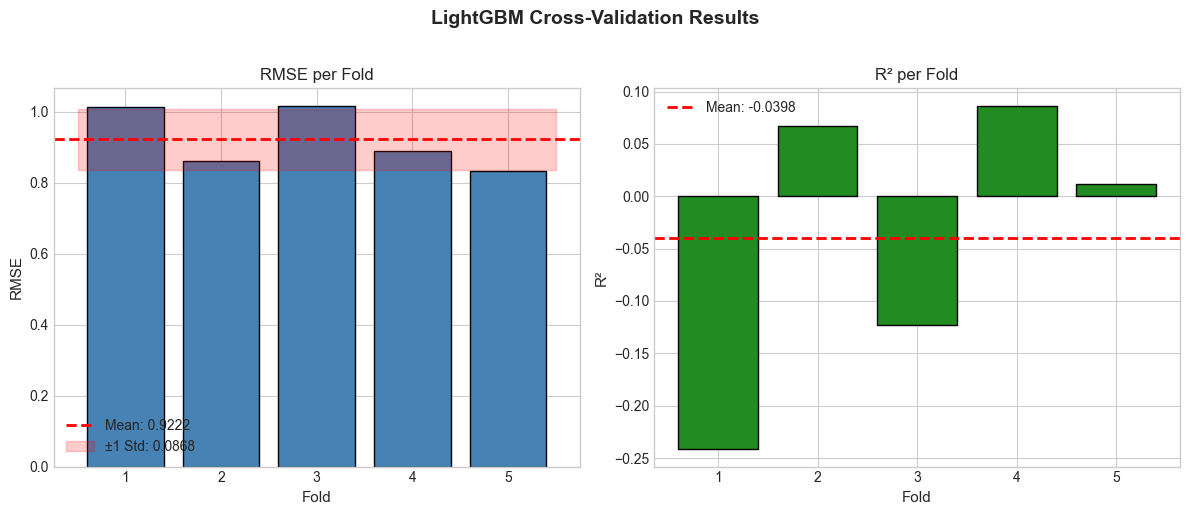

In [23]:
fig = plot_cv_results(cv_results, title='LightGBM Cross-Validation Results')
plt.show()

## 9. Feature Importance

In [24]:
importance_df = pd.DataFrame({
    'feature': feature_list,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 20 Most Important Features:')
print(importance_df.head(20).to_string(index=False))

Top 20 Most Important Features:
            feature  importance
                pid        7086
     stocks_per_day        1992
 day_std_median_vol         631
                 LS         593
day_mean_median_vol         554
   NLV_per_pid_mean         440
   day_mean_sum_ret         389
    NLV_rank_in_day         301
    NLV_per_pid_std         289
   day_mean_std_ret         288
    day_std_sum_ret         286
      NLV_x_std_ret         279
      NLV_deviation         270
         NLV_zscore         192
         median_ret         185
                NLV         160
            sum_ret         157
   NLV_x_median_vol         143
           rel_vol0         106
            min_vol         100


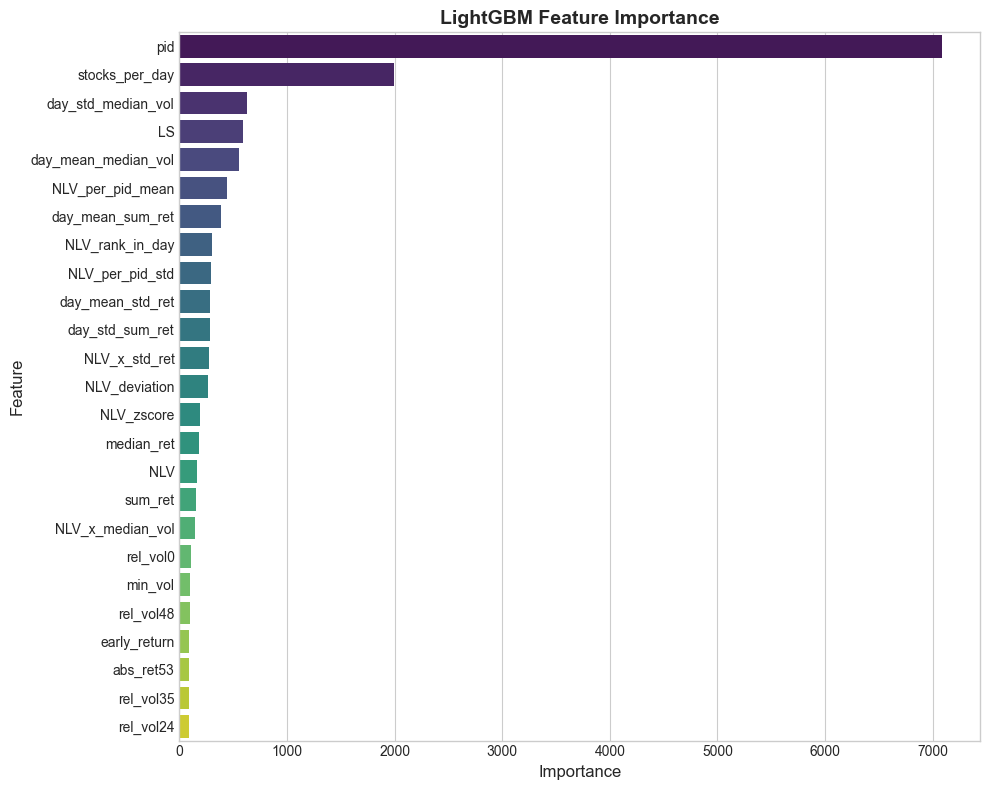

In [25]:
fig = plot_feature_importance(importance_df, top_n=25, title='LightGBM Feature Importance')
plt.show()

## 10. Model Analysis

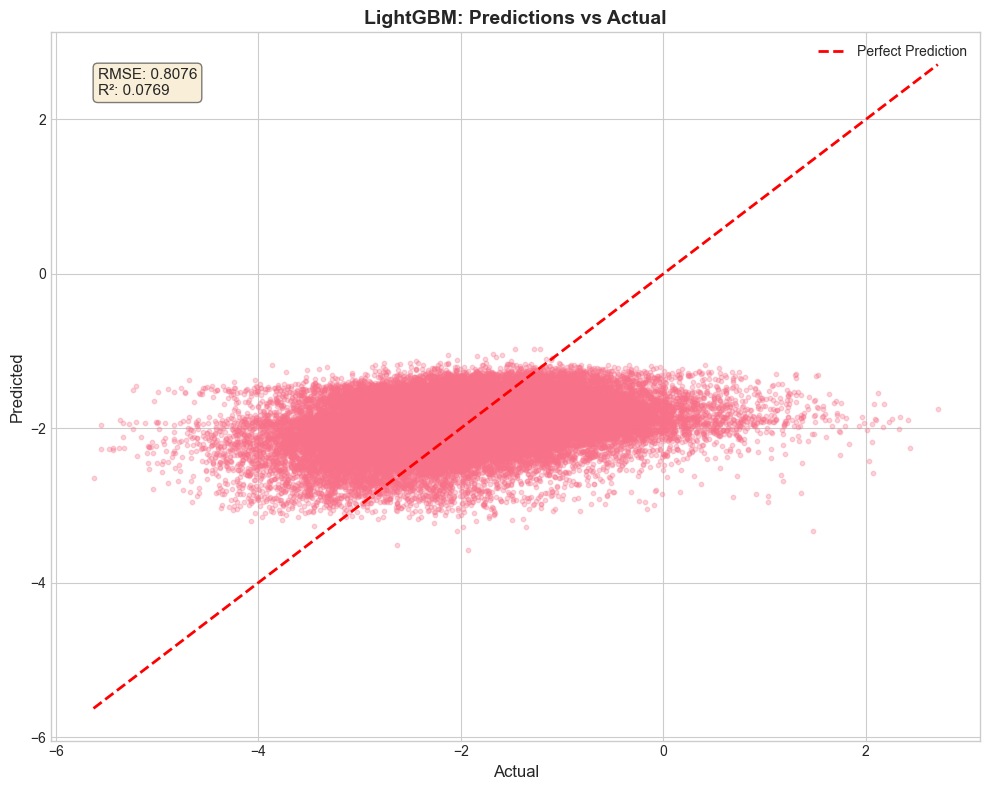

In [26]:
fig = plot_predictions(y_val.values, lgb_val_pred, title='LightGBM: Predictions vs Actual')
plt.show()

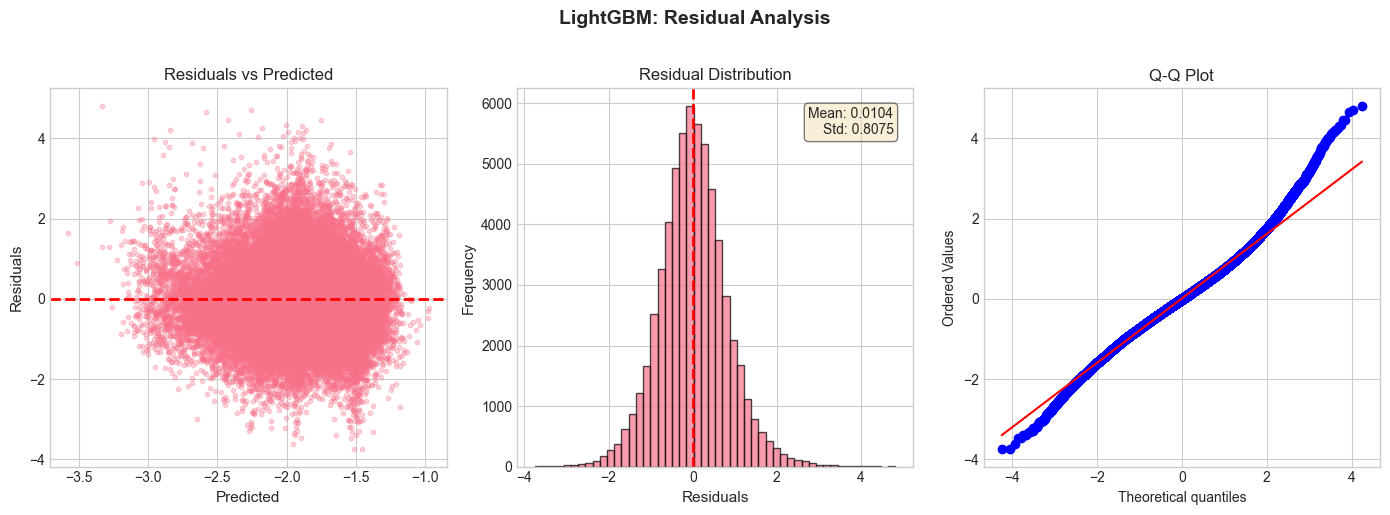

In [27]:
fig = plot_residuals(y_val.values, lgb_val_pred, title='LightGBM: Residual Analysis')
plt.show()

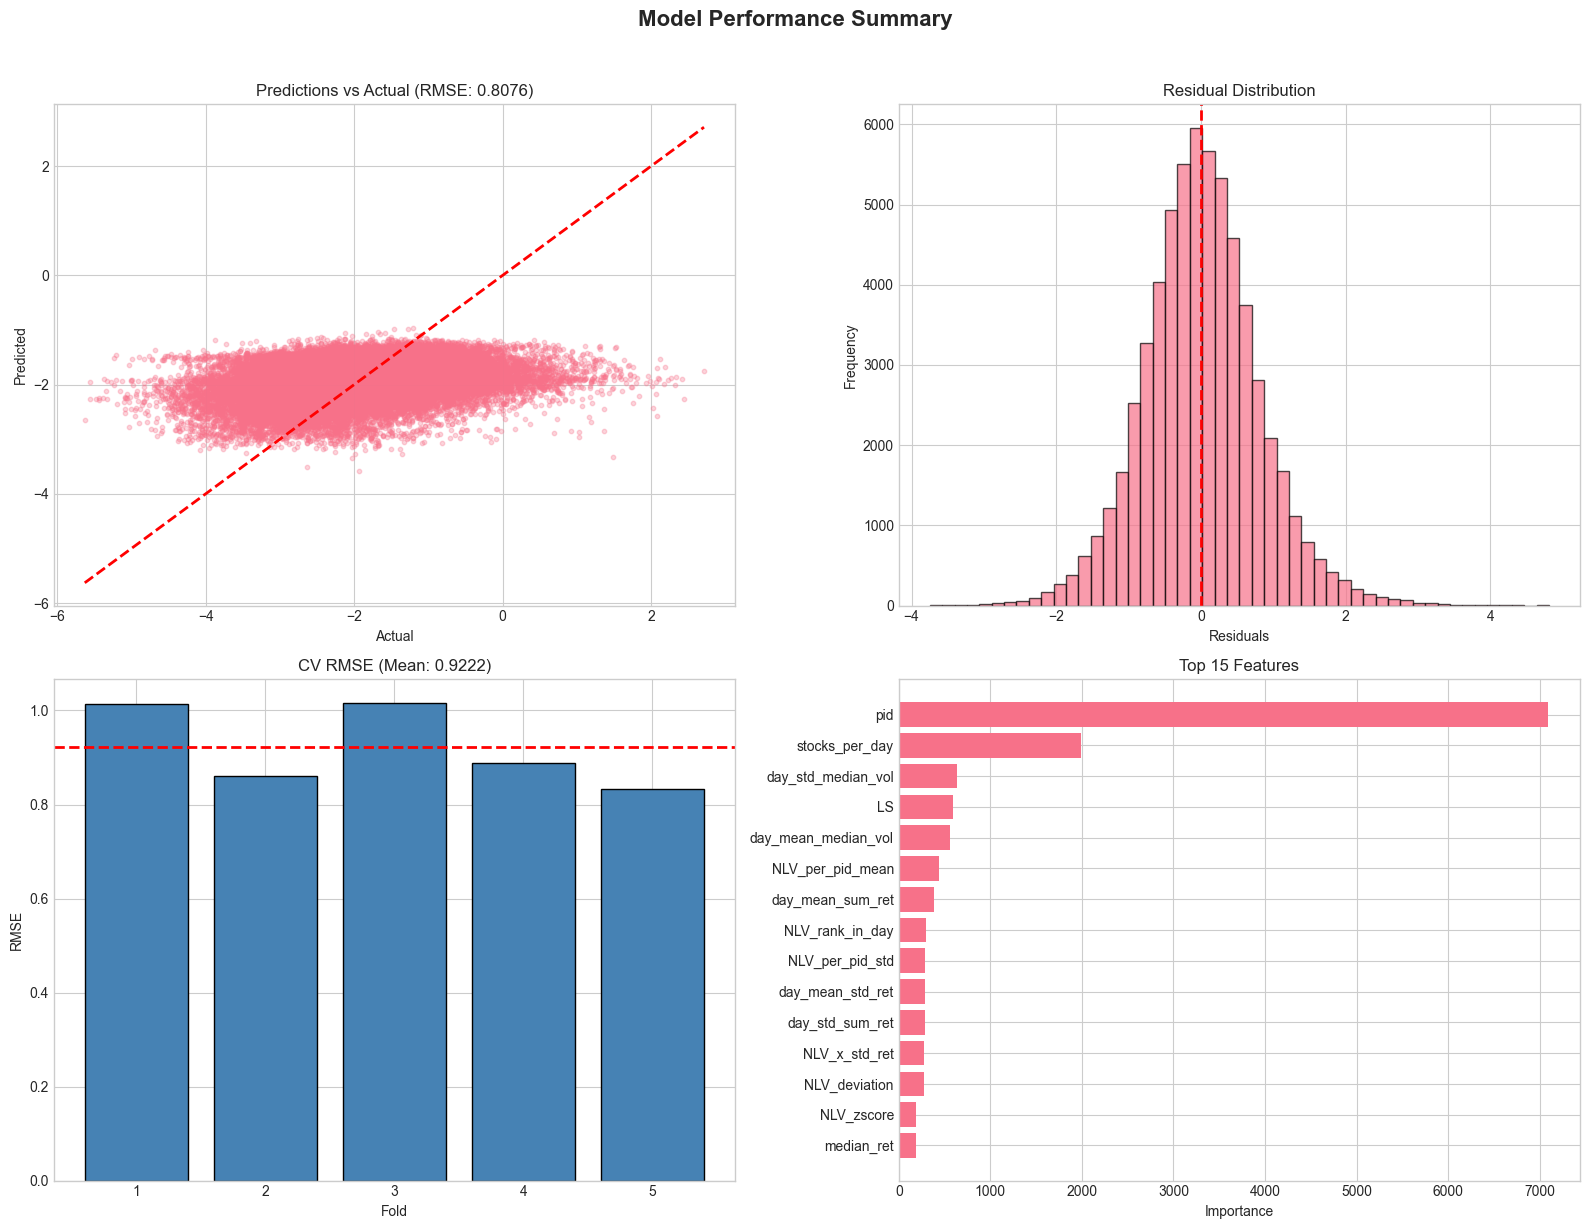

In [28]:
fig = create_summary_dashboard(
    y_true=y_val.values,
    y_pred=lgb_val_pred,
    cv_results=cv_results,
    feature_importance=importance_df
)
plt.show()

## 11. Final Model and Submission

In [ ]:
print('Running score-improvement workstream (tuning + CatBoost + stacking)...')

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import json

improvement_results = {}

# ------------------------------------------------------------------
# 1) LightGBM tuning (time-budgeted by default; increase n_trials for full run)
# ------------------------------------------------------------------
try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

base_lgb_params = config['models']['lightgbm']['params'].copy()

# Use a time-budgeted subset for tuning speed in notebook runs
tune_idx = np.arange(len(X_train))[::3]
X_train_tune = X_train.iloc[tune_idx]
y_train_tune = y_train_split.iloc[tune_idx]

if OPTUNA_AVAILABLE:
    def objective(trial):
        params = base_lgb_params.copy()
        params.update({
            'num_leaves': trial.suggest_int('num_leaves', 24, 96),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 50, 350),
            'subsample': trial.suggest_float('subsample', 0.5, 0.95),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 8.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 40.0),
        })

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_train_tune,
            y_train_tune,
            eval_set=[(X_val, y_val)],
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        val_pred = model.predict(X_val)
        return float(np.sqrt(mean_squared_error(y_val, val_pred)))

    n_trials = min(config.get('tuning', {}).get('n_trials', 20), 20)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    tuned_lgb_params = base_lgb_params.copy()
    tuned_lgb_params.update(study.best_params)
    print(f'Optuna complete: best RMSE={study.best_value:.4f}, trials={n_trials}')
else:
    tuned_lgb_params = base_lgb_params.copy()
    print('Optuna not available; using base LightGBM params')

# Fit tuned LightGBM on full train split
lgb_tuned_model = lgb.LGBMRegressor(**tuned_lgb_params)
lgb_tuned_model.fit(
    X_train,
    y_train_split,
    eval_set=[(X_val, y_val)],
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

lgb_tuned_train_pred = lgb_tuned_model.predict(X_train)
lgb_tuned_val_pred = lgb_tuned_model.predict(X_val)

lgb_tuned_train_metrics = compute_metrics(y_train_split.values, lgb_tuned_train_pred)
lgb_tuned_val_metrics = compute_metrics(y_val.values, lgb_tuned_val_pred)
improvement_results['lgb_tuned'] = lgb_tuned_val_metrics

print('\nTUNED LIGHTGBM')
print(f'  Train RMSE: {lgb_tuned_train_metrics["rmse"]:.4f}')
print(f'  Val RMSE:   {lgb_tuned_val_metrics["rmse"]:.4f}')
print(f'  Val R2:     {lgb_tuned_val_metrics["r2"]:.4f}')

# ------------------------------------------------------------------
# 2) CatBoost baseline (optional if package available)
# ------------------------------------------------------------------
catboost_available = False
cat_val_metrics = None
cat_val_pred = None

try:
    from catboost import CatBoostRegressor
    catboost_available = True

    cat_model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.05,
        depth=7,
        l2_leaf_reg=10,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=SEED,
        verbose=False,
    )

    cat_model.fit(
        X_train,
        y_train_split,
        eval_set=(X_val, y_val),
        cat_features=categorical_cols,
        use_best_model=True,
    )

    cat_train_pred = cat_model.predict(X_train)
    cat_val_pred = cat_model.predict(X_val)

    cat_train_metrics = compute_metrics(y_train_split.values, cat_train_pred)
    cat_val_metrics = compute_metrics(y_val.values, cat_val_pred)
    improvement_results['catboost'] = cat_val_metrics

    print('\nCATBOOST')
    print(f'  Train RMSE: {cat_train_metrics["rmse"]:.4f}')
    print(f'  Val RMSE:   {cat_val_metrics["rmse"]:.4f}')
    print(f'  Val R2:     {cat_val_metrics["r2"]:.4f}')

except ImportError:
    print('\nCatBoost not installed; skipping CatBoost model')

# ------------------------------------------------------------------
# 3) OOF stacking (TwoStage + Tuned LGB + CatBoost if available)
# ------------------------------------------------------------------
stack_validator = TimeSeriesValidator(n_splits=3, gap=5, config=config)
stack_split_df = train_split[[day_col]]

two_stage_stack_model = TwoStageModel(
    linear_alpha=1.0,
    lgb_params=tuned_lgb_params,
    categorical_features=categorical_cols if categorical_cols else None,
    early_stopping_rounds=50,
    config=config,
)

ts_oof = cross_validate(
    model=two_stage_stack_model,
    X=X_train,
    y=y_train_split,
    validator=stack_validator,
    split_df=stack_split_df,
    config=config,
    verbose=False,
)

lgb_oof = cross_validate(
    model=lgb.LGBMRegressor(**tuned_lgb_params),
    X=X_train,
    y=y_train_split,
    validator=stack_validator,
    split_df=stack_split_df,
    fit_kwargs={'categorical_feature': cat_features},
    config=config,
    verbose=False,
)

stack_features = [ts_oof['oof_predictions'], lgb_oof['oof_predictions']]
stack_val_inputs = [ts_val_pred, lgb_tuned_val_pred]

if catboost_available:
    cat_oof = cross_validate(
        model=CatBoostRegressor(
            iterations=600,
            learning_rate=0.05,
            depth=7,
            l2_leaf_reg=10,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=SEED,
            verbose=False,
        ),
        X=X_train,
        y=y_train_split,
        validator=stack_validator,
        split_df=stack_split_df,
        fit_kwargs={'cat_features': categorical_cols},
        config=config,
        verbose=False,
    )
    stack_features.append(cat_oof['oof_predictions'])
    stack_val_inputs.append(cat_val_pred)

stack_matrix = np.column_stack(stack_features)
stack_valid_mask = np.ones(len(stack_matrix), dtype=bool)
for arr in stack_features:
    stack_valid_mask &= np.isfinite(arr)

meta_model = Ridge(alpha=1.0)
meta_model.fit(stack_matrix[stack_valid_mask], y_train_split.values[stack_valid_mask])

stack_val_matrix = np.column_stack(stack_val_inputs)
stack_val_pred = meta_model.predict(stack_val_matrix)
stack_val_metrics = compute_metrics(y_val.values, stack_val_pred)
improvement_results['stacked'] = stack_val_metrics

print('\nOOF STACKING (Ridge Meta)')
print(f'  Val RMSE: {stack_val_metrics["rmse"]:.4f}')
print(f'  Val R2:   {stack_val_metrics["r2"]:.4f}')

# ------------------------------------------------------------------
# Final model selection for submission
# ------------------------------------------------------------------
candidate_models = {
    'lightgbm_base': (lgb_model, lgb_val_metrics),
    'lightgbm_tuned': (lgb_tuned_model, lgb_tuned_val_metrics),
}

best_model_name = min(candidate_models.keys(), key=lambda name: candidate_models[name][1]['rmse'])
final_model = candidate_models[best_model_name][0]
final_val_metrics = candidate_models[best_model_name][1]

print('\nTraining final model on all training data...')
X_full = train_df[feature_list]
y_full = train_df[target_col]

if best_model_name == 'lightgbm_tuned':
    final_model = lgb.LGBMRegressor(**tuned_lgb_params)
else:
    final_model = lgb.LGBMRegressor(**lgb_params)

final_model.fit(X_full, y_full, categorical_feature=cat_features)

print(f'Final model trained: {best_model_name}')
print(f'Final selected val RMSE: {final_val_metrics["rmse"]:.4f}')


In [ ]:
print('Making predictions on test data...')

X_test_final = X_test_processed[feature_list]
print(f'Test data shape: {X_test_final.shape}')

test_predictions = final_model.predict(X_test_final)
print(f'Predictions shape: {test_predictions.shape}')
print(f'Predictions range: [{test_predictions.min():.4f}, {test_predictions.max():.4f}]')


In [ ]:
submission = create_submission(
    predictions=test_predictions,
    X_test=X_test_final,
    config=config,
    output_path='outputs/submission_phase1.csv',
    validate_against_example=True,
)

# Submission integrity checks
assert submission['ID'].isna().sum() == 0, 'Submission contains null IDs'
assert submission['ID'].duplicated().sum() == 0, 'Submission contains duplicate IDs'
assert len(submission) == len(X_test_final), 'Submission row count mismatch'

example_ids = pd.read_csv(config['data']['submission_example'], usecols=['ID'])
assert submission['ID'].iloc[0] == example_ids['ID'].iloc[0], 'First submission ID mismatch'
assert submission['ID'].iloc[-1] == example_ids['ID'].iloc[-1], 'Last submission ID mismatch'

print('Submission preview:')
print(submission.head(10))
print(f'Submission shape: {submission.shape}')
print(f'Submission ID range: [{submission["ID"].iloc[0]}, {submission["ID"].iloc[-1]}]')


## 12. Results Summary

In [ ]:
print('=' * 60)
print('ALIGNMENT-FIRST RESULTS SUMMARY')
print('=' * 60)
print('Canonical baseline anchored to current data behavior (NLV RMSE ~0.889)')
print('Model Performance (Validation Set):')
print(f'  1. NLV Only (Baseline):        RMSE = {nlv_val_metrics["rmse"]:.4f}')
print(f'  2. Two-Stage (Linear+LGB):     RMSE = {ts_val_metrics["rmse"]:.4f}')
print(f'  3. LightGBM Base:              RMSE = {lgb_val_metrics["rmse"]:.4f}')
print(f'  4. LightGBM Tuned:             RMSE = {lgb_tuned_val_metrics["rmse"]:.4f}')
if 'catboost' in improvement_results:
    print(f'  5. CatBoost:                   RMSE = {improvement_results["catboost"]["rmse"]:.4f}')
print(f'  6. OOF Stack (Ridge Meta):     RMSE = {improvement_results["stacked"]["rmse"]:.4f}')
print('\nCross-Validation (5-fold TimeSeriesSplit, gap=5, day excluded from features):')
print(f'  LightGBM CV RMSE: {cv_results["mean_rmse"]:.4f} +/- {cv_results["std_rmse"]:.4f}')

# Persist regression checks + metrics report
metrics_report = {
    'baseline': {
        'nlv_only': nlv_val_metrics,
        'two_stage': ts_val_metrics,
        'lightgbm_base': lgb_val_metrics,
    },
    'improvements': improvement_results,
    'cv': {
        'mean_rmse': float(cv_results['mean_rmse']),
        'std_rmse': float(cv_results['std_rmse']),
        'mean_mae': float(cv_results['mean_mae']),
        'std_mae': float(cv_results['std_mae']),
        'mean_r2': float(cv_results['mean_r2']),
        'std_r2': float(cv_results['std_r2']),
    },
}

Path('outputs').mkdir(parents=True, exist_ok=True)
with open('outputs/metrics_alignment_first.json', 'w') as f:
    json.dump(metrics_report, f, indent=2)

print('\nMetrics report saved: outputs/metrics_alignment_first.json')
print('=' * 60)
